# 13 — Réponses aux 9 questions de synthèse

**Objectif** — répondre, avec un tableau et/ou une figure à l'appui de chaque
réponse, aux neuf questions posées pour ce chantier :

1. Quels motifs et sous-motifs génèrent le plus fort volume, une fois les
   deux sources consolidées et les doublons retirés ?
2. Quelles catégories de réclamation concentrent le plus de tickets ?
3. Quels canaux, et quelles agences (propre au Système B), concentrent le
   plus de réclamations ?
4. Quelles catégories, bien que faibles en volume, concentrent les montants
   financiers les plus élevés ?
5. Existe-t-il une tendance temporelle (dégradation, pic) nécessitant une
   investigation ciblée ?
6. Pour chaque problème identifié, quelle action corrective est envisageable
   et quel service en a la charge ?
7. Dans quelle mesure les deux systèmes se recoupent-ils, et que capte le
   second outil que Intercom ne capte pas (et réciproquement) ?
8. La reconstruction automatique des sous-motifs à partir du texte libre
   Intercom est-elle fiable, mesurée contre la qualification annotée à la
   main du Système B ?
9. La méthode d'analyse est-elle reproductible sur un prochain export de
   chacune des deux sources ?

| | |
|---|---|
| **Entrée** | Système A (notebooks 01-07), Système B dédupliqué (notebooks 08-10), validation croisée (notebook 11) |
| **Sorties** | `resultats/tables/13_q*_*.csv` + `resultats/figures/13_q*_*.png` |

Ce notebook ne recalcule rien de nouveau sur le fond : il **réutilise** les
fonctions déjà validées de `src/reclamations/` (mêmes définitions, mêmes
seuils que les notebooks 04, 09, 10, 11, 12) et les réorganise question par
question, avec une figure en plus là où les notebooks sources n'en avaient
pas encore (matrice de confusion, recoupement A/B, exposition par catégorie).
Toute réserve méthodologique déjà posée dans ces notebooks (montants =
ordres de grandeur, rappel des règles plafonné, dédoublonnage = plancher)
reste valable ici et n'est pas répétée à chaque section.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent
sys.path.insert(0, str(RACINE / "src"))

import matplotlib.pyplot as plt
import pandas as pd

from reclamations import chargement, config, consolidation, systeme_b, texte, viz

viz.appliquer_charte()
pd.set_option("display.width", 160)

# --- Système A : périmètre opérationnel complet + classification causale ---
df_a = chargement.typer(chargement.charger_brut())
tickets_a = chargement.perimetre_operationnel(df_a)
messages = chargement.charger_messages_ouverture()
tickets_a = tickets_a.copy()
tickets_a["texte"] = chargement.construire_texte_enrichi(tickets_a, messages)
tickets_a["a_texte"] = texte.a_texte_exploitable(tickets_a["texte"])
tickets_a["famille"] = texte.classer(tickets_a["texte"])

# --- Système B : chargement complet, puis dédupliqué (notebook 09) ---
tickets_b_brut = systeme_b.charger_tickets()
categories_b = systeme_b.charger_categories()
groups_b = systeme_b.charger_groups()
champs_b, valeurs_b = systeme_b.charger_champs_personnalises()
sous_motifs_b = systeme_b.sous_motifs(champs_b, valeurs_b)

cles_a = consolidation.cles_a(tickets_a)
cles_b = consolidation.cles_b(tickets_b_brut, champs_b, valeurs_b)
paires = consolidation.apparier(cles_a, cles_b)
tickets_b = consolidation.tickets_b_non_apparies(tickets_b_brut, paires)

print(f"Système A (période opérationnelle)      : {len(tickets_a):,}")
print(f"Système B (brut, avant dédoublonnage)    : {len(tickets_b_brut):,}")
print(f"Système B (dédupliqué)                   : {len(tickets_b):,}")
print(f"TOTAL CONSOLIDÉ (A + B dédupliqué)        : {len(tickets_a) + len(tickets_b):,}")

/home/gauss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)
/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


/home/gauss/Bureau/Afriland/analyse des reclamation clients/niv/src/reclamations/texte.py:261: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  correspond = texte.str.contains(motif, regex=True, na=False)


Système A (période opérationnelle)      : 18,056
Système B (brut, avant dédoublonnage)    : 8,005
Système B (dédupliqué)                   : 6,823
TOTAL CONSOLIDÉ (A + B dédupliqué)        : 24,879


## Q1 — Motifs et sous-motifs les plus fréquents, sources consolidées et dédupliquées

Les deux systèmes portent deux taxonomies différentes, non fusionnées (le
notebook 11 n'a validé un pont que pour 2 des 6 familles de A — voir Q8) :
les deux tables sont donc présentées côte à côte, jamais additionnées.

In [2]:
base_a = tickets_a[tickets_a["a_texte"]]
familles_a = texte.couverture(base_a["famille"])
chargement.sauver_table(familles_a, "13_q1_familles_causales_a")

sm_b = sous_motifs_b.loc[sous_motifs_b.index.isin(tickets_b["id"])]
resume_sm_b = (
    sm_b.groupby(["domaine", "sous_motif"]).size().rename("effectif").reset_index()
    .sort_values("effectif", ascending=False)
)
resume_sm_b["pct"] = (resume_sm_b["effectif"] / len(sm_b) * 100).round(1)
chargement.sauver_table(resume_sm_b, "13_q1_sous_motifs_b", index=False)

print("Système A -- familles causales, règles (base textuelle, plancher -- notebook 04) :")
print(familles_a[["libelle", "effectif", "pct"]])
print()
print("Système B -- 10 sous-motifs annotés à la main les plus fréquents (dédupliqué) :")
print(resume_sm_b.head(10).to_string(index=False))

  -> resultats/tables/13_q1_familles_causales_a.csv
  -> resultats/tables/13_q1_sous_motifs_b.csv
Système A -- familles causales, règles (base textuelle, plancher -- notebook 04) :
                                                            libelle  effectif   pct
famille                                                                            
non_classe                                Non classé par les règles      4759  46.0
debit_non_credit       Débité sans que le bénéficiaire soit crédité      3830  37.0
erreur_client     Erreur de saisie du client (mauvais bénéficiaire)       643   6.2
acces_otp                     Accès bloqué / OTP / authentification       496   4.8
debit_injustifie       Débit injustifié, doublé, ou frais contestés       312   3.0
carte                                 Carte bancaire / distributeur       230   2.2
demande_info            Demande d'information (pas une réclamation)        84   0.8

Système B -- 10 sous-motifs annotés à la main les plus fréquen

  -> resultats/figures/13_q1_familles_a.png


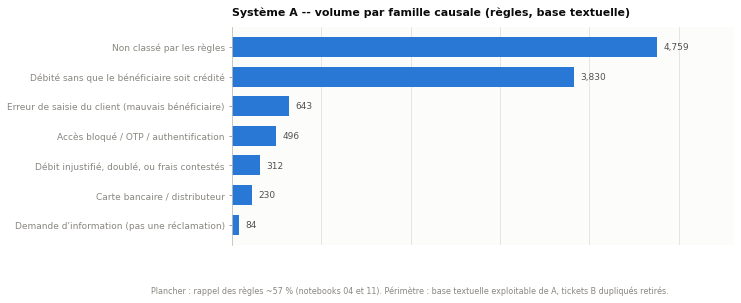

  -> resultats/figures/13_q1_sous_motifs_b.png


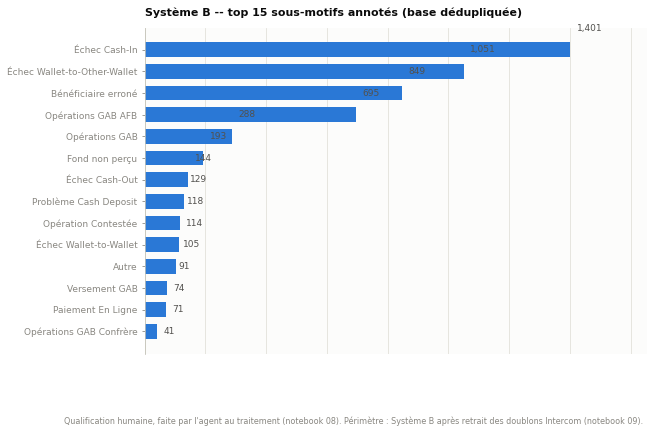

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
viz.barres_horizontales(
    familles_a.set_index("libelle")["effectif"],
    "Système A -- volume par famille causale (règles, base textuelle)",
    ax=ax,
)
viz.annoter_source(
    fig,
    "Plancher : rappel des règles ~57 % (notebooks 04 et 11). "
    "Périmètre : base textuelle exploitable de A, tickets B dupliqués retirés.",
)
viz.sauver(fig, "13_q1_familles_a")
plt.show()

top_sm_b = resume_sm_b.set_index("sous_motif")["effectif"].head(15)
fig, ax = plt.subplots(figsize=(9, 6))
viz.barres_horizontales(top_sm_b, "Système B -- top 15 sous-motifs annotés (base dédupliquée)", ax=ax)
viz.annoter_source(
    fig,
    "Qualification humaine, faite par l'agent au traitement (notebook 08). "
    "Périmètre : Système B après retrait des doublons Intercom (notebook 09).",
)
viz.sauver(fig, "13_q1_sous_motifs_b")
plt.show()

## Q2 — Catégories qui concentrent le plus de tickets

`ticket_type_name` (A) et la catégorie du Système B (`categories.xlsx`) sont
la classification produit choisie au dépôt — pas la cause du problème (Q1) :
un même incident (ex. transfert non abouti) peut être classé en catégorie
SARA côté A. Les deux nomenclatures ne sont pas identiques, présentées côte
à côte.

In [4]:
cat_a = tickets_a["ticket_type_name"].value_counts().rename("effectif").to_frame()
cat_a["pct"] = (cat_a["effectif"] / len(tickets_a) * 100).round(1)
chargement.sauver_table(cat_a, "13_q2_categories_a")

noms_categories_b = tickets_b["category_id"].map(categories_b.set_index("id")["name"])
cat_b = noms_categories_b.value_counts().rename("effectif").to_frame()
cat_b["pct"] = (cat_b["effectif"] / len(tickets_b) * 100).round(1)
chargement.sauver_table(cat_b, "13_q2_categories_b")

print("Système A -- ticket_type_name :")
print(cat_a)
print()
print("Système B (dédupliqué) -- catégorie :")
print(cat_b)

  -> resultats/tables/13_q2_categories_a.csv
  -> resultats/tables/13_q2_categories_b.csv
Système A -- ticket_type_name :
                            effectif   pct
ticket_type_name                          
SARA                           10678  59.1
COMPTE                          4919  27.2
CARTE                            681   3.8
BENEFICIAIRE ERRONE              572   3.2
CREDIT                           387   2.1
ACCUEIL                          278   1.5
OPERATIONS_INTERNATIONALES       172   1.0
MAC                              159   0.9
CARTE_BLANCHE                     88   0.5
EFIRST                            86   0.5
DECOUVERT                         32   0.2
JUSTIFS AVI                        4   0.0

Système B (dédupliqué) -- catégorie :
                                 effectif   pct
category_id                                    
SARA                                 4009  58.8
CARTE                                1368  20.0
MAC                                   573   8

  -> resultats/figures/13_q2_categories_a.png


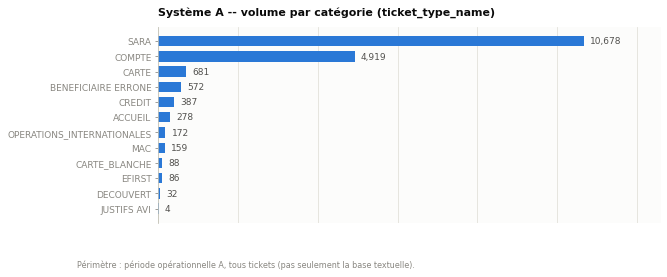

  -> resultats/figures/13_q2_categories_b.png


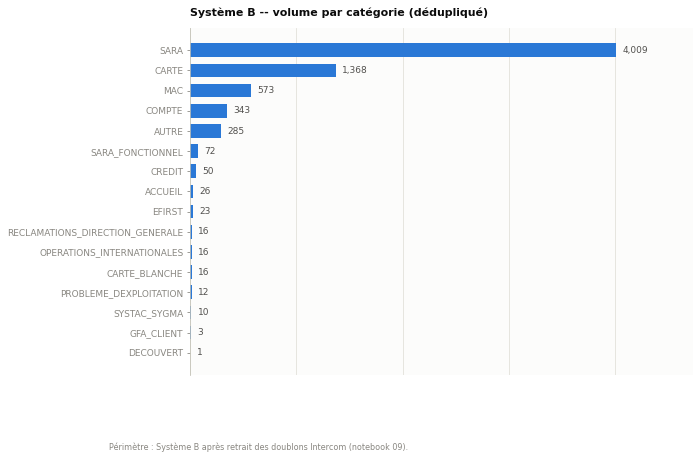

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
viz.barres_horizontales(cat_a["effectif"], "Système A -- volume par catégorie (ticket_type_name)", ax=ax)
viz.annoter_source(fig, "Périmètre : période opérationnelle A, tous tickets (pas seulement la base textuelle).")
viz.sauver(fig, "13_q2_categories_a")
plt.show()

fig, ax = plt.subplots(figsize=(9, max(3.6, 0.4 * len(cat_b))))
viz.barres_horizontales(cat_b["effectif"], "Système B -- volume par catégorie (dédupliqué)", ax=ax)
viz.annoter_source(fig, "Périmètre : Système B après retrait des doublons Intercom (notebook 09).")
viz.sauver(fig, "13_q2_categories_b")
plt.show()

## Q3 — Canaux, et agences (propre au Système B)

`channel` (A) décrit le sous-canal digital Intercom. `canal` (B) décrit le
canal d'intake au sens large (agence, courrier, appel, mail, INTERCOM
ressaisi...). L'agence n'existe que côté B — c'est une dimension que A ne
peut, par construction, jamais apporter.

In [6]:
canal_a = tickets_a["channel"].value_counts().rename("effectif").to_frame()
canal_a["pct"] = (canal_a["effectif"] / len(tickets_a) * 100).round(1)
canal_b = tickets_b["canal"].value_counts().rename("effectif").to_frame()
canal_b["pct"] = (canal_b["effectif"] / len(tickets_b) * 100).round(1)
chargement.sauver_table(canal_a, "13_q3_canal_a")
chargement.sauver_table(canal_b, "13_q3_canal_b")

noms_groupes = tickets_b["source_group_id"].map(groups_b.set_index("id")["group_name"])
est_agence = noms_groupes.str.startswith("FIRST_BANK_", na=False)
agences = noms_groupes[est_agence].value_counts().rename("effectif").to_frame().head(15)
agences["pct_des_tickets_agence"] = (agences["effectif"] / est_agence.sum() * 100).round(1)
chargement.sauver_table(agences, "13_q3_top_agences")

print("Système A -- channel :")
print(canal_a)
print()
print("Système B (dédupliqué) -- canal :")
print(canal_b)
print()
print(f"Top 15 agences, sur {int(est_agence.sum()):,} tickets B rattachés à une agence :")
print(agences)

  -> resultats/tables/13_q3_canal_a.csv
  -> resultats/tables/13_q3_canal_b.csv
  -> resultats/tables/13_q3_top_agences.csv
Système A -- channel :
           effectif   pct
channel                  
android       11857  65.7
ios            3711  20.6
whatsapp       2297  12.7
facebook        181   1.0
messenger         7   0.0
instagram         3   0.0

Système B (dédupliqué) -- canal :
           effectif   pct
canal                    
INTERCOM       2291  33.6
EN_AGENCE      1970  28.9
COURRIER        995  14.6
APPEL           470   6.9
COLLEGUE        322   4.7
MAIL            286   4.2
WHATSAPP        243   3.6
AUTRE           241   3.5

Top 15 agences, sur 2,806 tickets B rattachés à une agence :
                                      effectif  pct_des_tickets_agence
source_group_id                                                       
FIRST_BANK_HIPPODROME                      255                     9.1
FIRST_BANK_NGAOUNDERE                      254                     9.1
FIRS

  -> resultats/figures/13_q3_canal_a.png


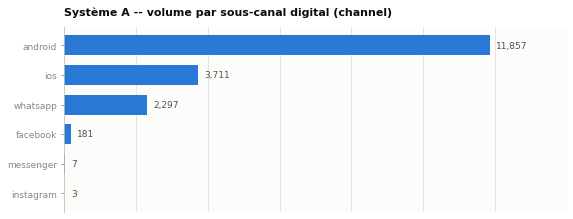

  -> resultats/figures/13_q3_canal_b.png


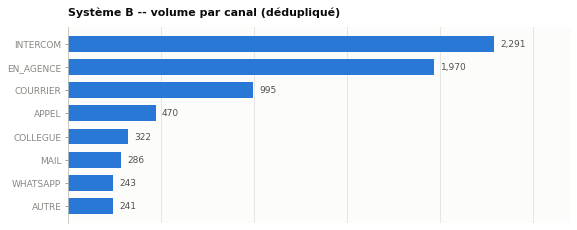

  -> resultats/figures/13_q3_top_agences.png


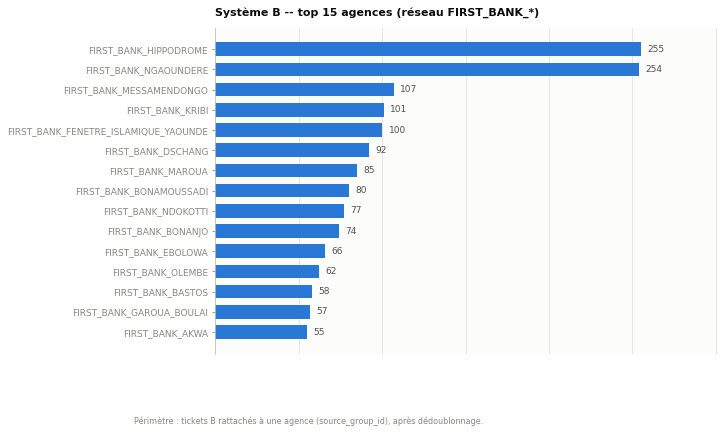

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.4))
viz.barres_horizontales(canal_a["effectif"], "Système A -- volume par sous-canal digital (channel)", ax=ax)
viz.sauver(fig, "13_q3_canal_a")
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.6))
viz.barres_horizontales(canal_b["effectif"], "Système B -- volume par canal (dédupliqué)", ax=ax)
viz.sauver(fig, "13_q3_canal_b")
plt.show()

fig, ax = plt.subplots(figsize=(9, max(3.6, 0.4 * len(agences))))
viz.barres_horizontales(agences["effectif"], "Système B -- top 15 agences (réseau FIRST_BANK_*)", ax=ax)
viz.annoter_source(fig, "Périmètre : tickets B rattachés à une agence (source_group_id), après dédoublonnage.")
viz.sauver(fig, "13_q3_top_agences")
plt.show()

## Q4 — Catégories à faible volume mais forte exposition financière

Montants **plausibles uniquement** (`chargement.montants_plausibles` /
`systeme_b.montants_plausibles` : strictement positifs, sous le plafond de
vraisemblance) — ordre de grandeur, jamais un chiffre officiel (protocole
§ 8.4). On lit la **médiane**, insensible aux valeurs extrêmes, comme au
notebook 04 § 7.

In [8]:
mt_a_cat = chargement.montants_plausibles(tickets_a)
expo_cat_a = mt_a_cat.groupby("ticket_type_name")["montant"].agg(
    tickets="count", mediane="median", total="sum"
).sort_values("mediane", ascending=False)
chargement.sauver_table(expo_cat_a.round(0), "13_q4_exposition_categorie_a")

mt_b = systeme_b.montants_plausibles(champs_b, valeurs_b)
mt_b_dedup = mt_b.loc[mt_b.index.isin(tickets_b["id"])]
cat_par_id = tickets_b.set_index("id")["category_id"].map(categories_b.set_index("id")["name"])
expo_cat_b = pd.DataFrame(
    {"montant": mt_b_dedup, "categorie": cat_par_id.reindex(mt_b_dedup.index)}
).groupby("categorie")["montant"].agg(
    tickets="count", mediane="median", total="sum"
).sort_values("mediane", ascending=False)
chargement.sauver_table(expo_cat_b.round(0), "13_q4_exposition_categorie_b")

print("Système A -- exposition financière par catégorie (triée par montant médian) :")
print(expo_cat_a.round(0))
print()
print("Système B -- exposition financière par catégorie (triée par montant médian) :")
print(expo_cat_b.round(0))

  -> resultats/tables/13_q4_exposition_categorie_a.csv
  -> resultats/tables/13_q4_exposition_categorie_b.csv
Système A -- exposition financière par catégorie (triée par montant médian) :
                            tickets   mediane        total
ticket_type_name                                          
CREDIT                           61  600000.0   92019674.0
OPERATIONS_INTERNATIONALES       32  290000.0   24228071.0
CARTE                            87  115000.0   17475805.0
COMPTE                         2417   51000.0  462152608.0
SARA                           4348   41700.0  504972005.0
EFIRST                            5   14000.0      97920.0

Système B -- exposition financière par catégorie (triée par montant médian) :
                                 tickets    mediane        total
categorie                                                       
CREDIT                                38  1040000.0  115036381.0
EFIRST                                 7  1000000.0   15300389.0
R

  -> resultats/figures/13_q4_volume_vs_montant.png


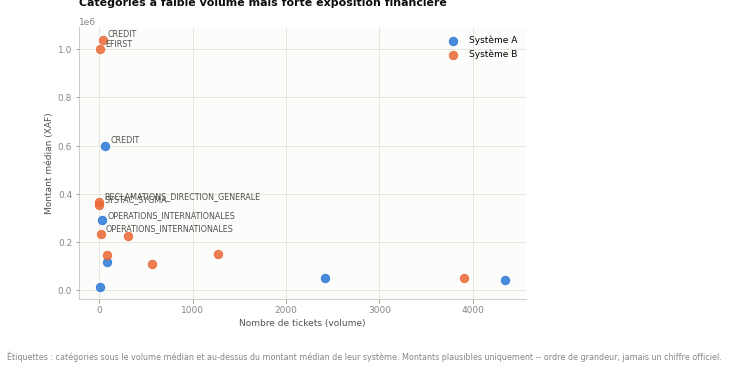

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for donnees, couleur, label in [(expo_cat_a, viz.SERIES[0], "Système A"), (expo_cat_b, viz.SERIES[1], "Système B")]:
    ax.scatter(donnees["tickets"], donnees["mediane"], s=70, color=couleur, alpha=0.85, label=label)
    seuil_volume = donnees["tickets"].median()
    seuil_montant = donnees["mediane"].median()
    for nom, ligne in donnees.iterrows():
        if ligne["tickets"] < seuil_volume and ligne["mediane"] > seuil_montant:
            ax.annotate(
                str(nom), (ligne["tickets"], ligne["mediane"]), fontsize=8,
                color=viz.ENCRE["secondaire"], xytext=(5, 3), textcoords="offset points",
            )
ax.set_xlabel("Nombre de tickets (volume)")
ax.set_ylabel("Montant médian (XAF)")
ax.set_title("Catégories à faible volume mais forte exposition financière")
ax.legend(frameon=False, fontsize=9)
viz.annoter_source(
    fig,
    "Étiquettes : catégories sous le volume médian et au-dessus du montant médian de leur système. "
    "Montants plausibles uniquement -- ordre de grandeur, jamais un chiffre officiel.",
)
viz.sauver(fig, "13_q4_volume_vs_montant")
plt.show()

## Q5 — Tendance temporelle

La rupture de collecte du 13/03/2026 (notebook 02) reste le seul événement
déjà daté avec certitude : pic de volume et effondrement simultané de la
complétude des champs, retour à la normale mi-mai. On y ajoute ici le volume
mensuel du Système B sur la même échelle de temps, jamais fait jusqu'ici,
pour voir s'il porte la même signature ou une tendance propre.

  -> resultats/figures/13_q5_volume_mensuel_a_b.png


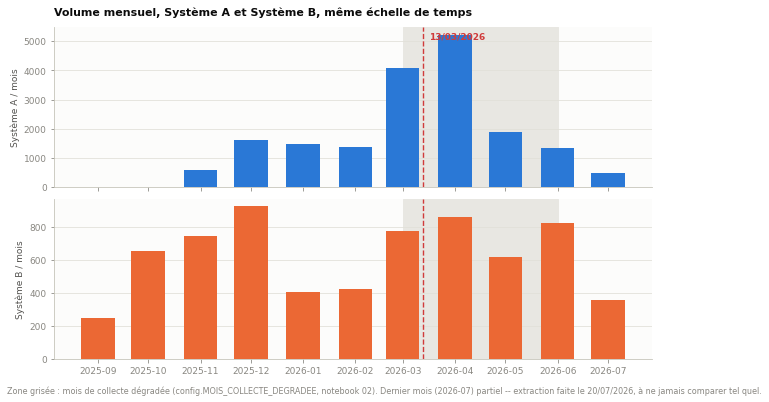

In [10]:
mensuel_a = tickets_a.set_index("date_creation")["id"].resample("MS").size()
mensuel_b = tickets_b.set_index("created_at")["id"].resample("MS").size()

toutes_dates = mensuel_a.index.union(mensuel_b.index)
mensuel_a = mensuel_a.reindex(toutes_dates, fill_value=0)
mensuel_b = mensuel_b.reindex(toutes_dates, fill_value=0)

zone_degradee = (
    config.MOIS_COLLECTE_DEGRADEE[0].start_time,
    config.MOIS_COLLECTE_DEGRADEE[-1].end_time,
)

fig, axes = viz.panneaux_temporels(
    toutes_dates,
    [
        {"valeurs": mensuel_a, "libelle": "Système A / mois", "couleur": viz.SERIES[0], "type": "barres", "largeur": 20},
        {"valeurs": mensuel_b, "libelle": "Système B / mois", "couleur": viz.SERIES[1], "type": "barres", "largeur": 20},
    ],
    titre="Volume mensuel, Système A et Système B, même échelle de temps",
    zone_grisee=zone_degradee,
    ligne_verticale=config.DATE_RUPTURE_COLLECTE,
    etiquette_ligne="13/03/2026",
)
viz.annoter_source(
    fig,
    "Zone grisée : mois de collecte dégradée (config.MOIS_COLLECTE_DEGRADEE, notebook 02). "
    f"Dernier mois ({config.MOIS_PARTIEL}) partiel -- extraction faite le 20/07/2026, à ne jamais comparer tel quel.",
)
viz.sauver(fig, "13_q5_volume_mensuel_a_b")
plt.show()

In [11]:
# Mois complets uniquement (le dernier mois de l'export est partiel, config.MOIS_PARTIEL)
complets_a = mensuel_a[mensuel_a.index.to_period("M") != config.MOIS_PARTIEL]
complets_b = mensuel_b[mensuel_b.index.to_period("M") != config.MOIS_PARTIEL]

tendance = pd.DataFrame({"Système A": complets_a, "Système B": complets_b})
tendance.index = tendance.index.to_period("M").astype(str)
chargement.sauver_table(tendance, "13_q5_volume_mensuel_complet")
print("Volume mensuel, mois complets uniquement :")
print(tendance)
print()
print(f"Système A -- 3 derniers mois complets : moyenne {complets_a.tail(3).mean():.0f} / mois")
print(f"Système A -- 3 mois complets précédents : moyenne {complets_a.iloc[-6:-3].mean():.0f} / mois")
print(f"Système B -- 3 derniers mois complets : moyenne {complets_b.tail(3).mean():.0f} / mois")
print(f"Système B -- 3 mois complets précédents : moyenne {complets_b.iloc[-6:-3].mean():.0f} / mois")

  -> resultats/tables/13_q5_volume_mensuel_complet.csv
Volume mensuel, mois complets uniquement :
         Système A  Système B
2025-09          0        250
2025-10          0        653
2025-11        600        743
2025-12       1605        924
2026-01       1467        402
2026-02       1372        422
2026-03       4087        773
2026-04       5228        858
2026-05       1874        619
2026-06       1333        821

Système A -- 3 derniers mois complets : moyenne 2812 / mois
Système A -- 3 mois complets précédents : moyenne 2309 / mois
Système B -- 3 derniers mois complets : moyenne 766 / mois
Système B -- 3 mois complets précédents : moyenne 532 / mois


## Q6 — Action corrective et service responsable, par problème

`texte.responsables()` associe déjà un responsable présumé à chaque famille
causale (notebook 04). On y ajoute une action corrective concrète par
famille, et les deux points que seul le Système B permet d'objectiver
(agence, canal non digital).

In [12]:
ACTIONS_CORRECTIVES = {
    "debit_non_credit": "Diagnostic technique de la chaîne SARA <-> opérateur mobile money (nécessite le journal de transactions, hors périmètre actuel)",
    "erreur_client": "Afficher le nom du titulaire du compte bénéficiaire avant validation du transfert (UX applicative)",
    "acces_otp": "Fiabiliser l'envoi/la validation de l'OTP, améliorer le message d'erreur de connexion",
    "debit_injustifie": "Revue des règles de frais/agios affichées au client avant tout prélèvement",
    "carte": "Audit du parc GAB/DAB et suivi des incidents monétique par distributeur",
    "demande_info": "Rediriger vers une FAQ / self-service -- hors périmètre réclamation",
    "non_classe": "Non actionnable tel quel -- nécessite la classification apprise (Q8) pour être requalifié",
}

table_q6 = familles_a.copy()
table_q6["action_corrective"] = table_q6.index.map(ACTIONS_CORRECTIVES)
chargement.sauver_table(table_q6, "13_q6_actions_correctives")
table_q6[["libelle", "responsable", "effectif", "pct", "action_corrective"]]

  -> resultats/tables/13_q6_actions_correctives.csv


,libelle,responsable,effectif,pct,action_corrective
famille,,,,,
non_classe,Non classé par les règles,Indéterminé,4759,46.0,Non actionnable tel quel -- nécessite la class...
debit_non_credit,Débité sans que le bénéficiaire soit crédité,Système (banque <-> opérateur),3830,37.0,Diagnostic technique de la chaîne SARA <-> opé...
erreur_client,Erreur de saisie du client (mauvais bénéficiaire),UX de l'application,643,6.2,Afficher le nom du titulaire du compte bénéfic...
acces_otp,Accès bloqué / OTP / authentification,Système (authentification),496,4.8,"Fiabiliser l'envoi/la validation de l'OTP, amé..."
debit_injustifie,"Débit injustifié, doublé, ou frais contestés",Système (banque),312,3.0,Revue des règles de frais/agios affichées au c...
carte,Carte bancaire / distributeur,Système (monétique),230,2.2,Audit du parc GAB/DAB et suivi des incidents m...
demande_info,Demande d'information (pas une réclamation),Hors périmètre réclamation,84,0.8,Rediriger vers une FAQ / self-service -- hors ...


**Deux points que seul le Système B rend actionnables** (pas de figure
supplémentaire — déjà visibles en Q3) :

| Problème | Ampleur | Responsable présumé | Action |
|---|---|---|---|
| Concentration géographique des réclamations | Agences en tête, § Q3 | Réseau d'agences concernées | Investigation ciblée sur les agences en tête de la table Q3 -- impossible avec A seul |
| Délai de traitement non mesurable côté A | Mesuré au notebook 10 § 5 | Responsable du support | Suivre ce délai comme KPI, en s'appuyant sur B où A ne le permet pas |

## Q7 — Recoupement entre les deux systèmes

Un taux d'appariement observé ne veut rien dire sans son bruit de fond
(`consolidation.bruit_de_fond`, même logique que le V de Cramér utilisé pour
la représentativité, notebook 03) : on le recalcule ici canal par canal, sur
100 permutations (notebook 09 § 3).

In [13]:
lignes = []
for canal_nom, ids_canal in tickets_b_brut.groupby("canal")["id"]:
    cb_canal = cles_b.loc[cles_b.index.isin(ids_canal)]
    obs = consolidation.apparier_telephone_montant_date(cles_a, cb_canal)
    n_obs = obs["ticket_id_b"].nunique()
    bruit = consolidation.bruit_de_fond(
        cles_a, cb_canal, methode="telephone_montant_date", n_permutations=100, graine=1
    )
    lignes.append({
        "canal": canal_nom,
        "n_tickets": len(cb_canal),
        "apparies_observes": n_obs,
        "pct_observe": round(n_obs / len(cb_canal) * 100, 1),
        "bruit_moyen": round(bruit["moyenne"], 2),
    })

taux_appariement = pd.DataFrame(lignes).sort_values("pct_observe", ascending=False)
chargement.sauver_table(taux_appariement, "13_q7_taux_appariement_par_canal", index=False)
taux_appariement

  -> resultats/tables/13_q7_taux_appariement_par_canal.csv


,canal,n_tickets,apparies_observes,pct_observe,bruit_moyen
5,INTERCOM,3180,688,21.6,3.11
0,APPEL,498,18,3.6,0.11
4,EN_AGENCE,2082,66,3.2,0.16
7,WHATSAPP,258,6,2.3,0.07
3,COURRIER,1031,18,1.7,0.07
2,COLLEGUE,345,6,1.7,0.06
1,AUTRE,301,5,1.7,0.06
6,MAIL,305,4,1.3,0.00


  -> resultats/figures/13_q7_taux_appariement_par_canal.png


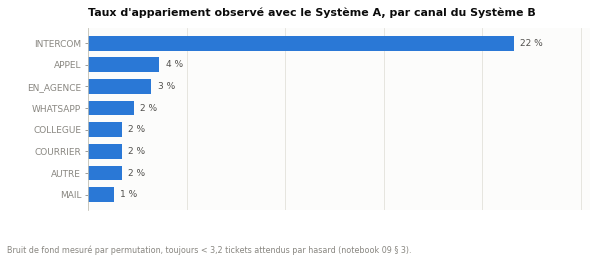

  -> resultats/tables/13_q7_recoupement_a_b.csv


  -> resultats/figures/13_q7_recoupement_a_b.png


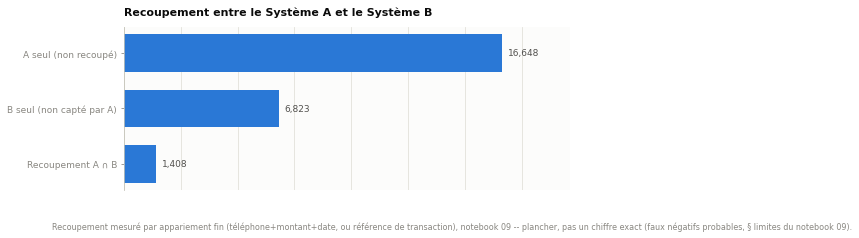

Canaux exclusifs au Système B (aucun équivalent dans A) : ['APPEL', 'AUTRE', 'COLLEGUE', 'COURRIER', 'EN_AGENCE', 'MAIL', 'WHATSAPP']
Sous-canaux digitaux exclusifs au Système A (channel)   : ['android', 'facebook', 'instagram', 'ios', 'messenger', 'whatsapp']
Dimension 'agence' : disponible uniquement dans B (100.0 % des tickets B dédupliqués rattachés à un groupe source).


In [14]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.42 * len(taux_appariement))))
viz.barres_horizontales(
    taux_appariement.set_index("canal")["pct_observe"],
    "Taux d'appariement observé avec le Système A, par canal du Système B",
    unite=" %",
    ax=ax,
)
viz.annoter_source(fig, "Bruit de fond mesuré par permutation, toujours < 3,2 tickets attendus par hasard (notebook 09 § 3).")
viz.sauver(fig, "13_q7_taux_appariement_par_canal")
plt.show()

n_a_total = len(tickets_a)
n_recoupe = paires["ticket_id_a"].nunique()
n_a_seul = n_a_total - n_recoupe
n_b_seul = len(tickets_b)  # déjà dédupliqué : ce qui reste par construction n'est capté que par B

recoupement = pd.Series({
    "A seul (non recoupé)": n_a_seul,
    "Recoupement A ∩ B": n_recoupe,
    "B seul (non capté par A)": n_b_seul,
})
chargement.sauver_table(recoupement.rename("effectif").to_frame(), "13_q7_recoupement_a_b")

fig, ax = plt.subplots(figsize=(8, 3))
viz.barres_horizontales(recoupement, "Recoupement entre le Système A et le Système B", ax=ax)
viz.annoter_source(
    fig,
    "Recoupement mesuré par appariement fin (téléphone+montant+date, ou référence de transaction), notebook 09 -- "
    "plancher, pas un chiffre exact (faux négatifs probables, § limites du notebook 09).",
)
viz.sauver(fig, "13_q7_recoupement_a_b")
plt.show()

canaux_b_only = sorted(set(tickets_b_brut["canal"].dropna().unique()) - {"INTERCOM"})
print(f"Canaux exclusifs au Système B (aucun équivalent dans A) : {canaux_b_only}")
print(f"Sous-canaux digitaux exclusifs au Système A (channel)   : {sorted(tickets_a['channel'].dropna().unique())}")
print(
    "Dimension 'agence' : disponible uniquement dans B "
    f"({tickets_b['source_group_id'].notna().mean() * 100:.1f} % des tickets B dédupliqués rattachés à un groupe source)."
)

## Q8 — Fiabilité de la reconstruction des sous-motifs (règles A vs annotation B)

Jeu de référence de fait (notebook 11) : sur les tickets appariés A↔B, le
sous-motif B (annotation humaine, indépendante du texte et des règles) sert
d'étalon pour juger `texte.classer()`. **Ce jeu est biaisé** — il ne couvre
que les tickets à la fois déposés digitalement et ressaisis manuellement
côté B, probablement les cas les plus clairs à qualifier (notebook 11 § 4).

In [15]:
jeu = paires[["ticket_id_a", "ticket_id_b", "methode"]].copy()
jeu["famille_a"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["famille"])
jeu["a_texte"] = jeu["ticket_id_a"].map(tickets_a.set_index("id")["a_texte"])
jeu = jeu.merge(sous_motifs_b, left_on="ticket_id_b", right_index=True, how="inner")
jeu = jeu.drop_duplicates(["ticket_id_a", "ticket_id_b"])
jeu = jeu[jeu["a_texte"] == True]
jeu = jeu.drop_duplicates("ticket_id_a")
print(f"Jeu de référence de fait (paires A↔B, sous-motif B + texte A exploitables) : {len(jeu):,} tickets")

confusion_brute = pd.crosstab(jeu["famille_a"], jeu["sous_motif"])
chargement.sauver_table(confusion_brute, "13_q8_confusion_brute")
confusion_brute

Jeu de référence de fait (paires A↔B, sous-motif B + texte A exploitables) : 950 tickets


  -> resultats/tables/13_q8_confusion_brute.csv


sous_motif,Autre,Bénéficiaire erroné,Fond non perçu,Opération Contestée,Opérations GAB,Opérations GAB AFB,Versement GAB,Échec Achat Air-Time,Échec Cash-In,Échec Cash-Out,Échec MAC Bank-to-Wallet,Échec Wallet-to-Other-Wallet,Échec Wallet-to-Wallet
famille_a,,,,,,,,,,,,,
acces_otp,0,1,0,0,0,0,0,0,26,0,0,1,0
carte,0,0,0,0,0,3,0,0,1,0,0,0,0
debit_injustifie,0,1,0,1,0,1,0,0,21,2,0,0,0
debit_non_credit,2,12,15,2,4,4,1,3,127,10,1,137,18
demande_info,0,0,0,0,0,0,0,0,0,0,0,3,0
erreur_client,0,178,3,0,0,0,0,0,5,0,0,5,0
non_classe,2,107,4,0,2,0,0,0,152,9,2,75,9


  -> resultats/figures/13_q8_confusion_heatmap.png


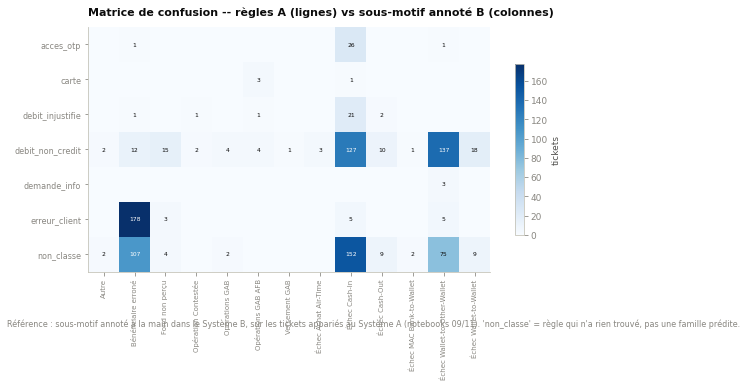

In [16]:
fig, ax = plt.subplots(figsize=(max(9, 0.5 * confusion_brute.shape[1]), max(4.5, 0.45 * confusion_brute.shape[0])))
matrice = confusion_brute.to_numpy()
im = ax.imshow(matrice, cmap="Blues", aspect="auto")
ax.set_xticks(range(confusion_brute.shape[1]))
ax.set_xticklabels(confusion_brute.columns, rotation=90, fontsize=7)
ax.set_yticks(range(confusion_brute.shape[0]))
ax.set_yticklabels(confusion_brute.index, fontsize=8)
seuil = matrice.max() * 0.6 if matrice.max() else 0
for i in range(confusion_brute.shape[0]):
    for j in range(confusion_brute.shape[1]):
        v = matrice[i, j]
        if v:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=6,
                     color="white" if v > seuil else viz.ENCRE["primaire"])
ax.set_title("Matrice de confusion -- règles A (lignes) vs sous-motif annoté B (colonnes)")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.7, label="tickets")
viz.annoter_source(
    fig,
    "Référence : sous-motif annoté à la main dans le Système B, sur les tickets appariés au Système A (notebooks 09/11). "
    "'non_classe' = règle qui n'a rien trouvé, pas une famille prédite.",
)
viz.sauver(fig, "13_q8_confusion_heatmap")
plt.show()

In [17]:
# Mapping écrit après lecture de la matrice brute (notebook 11 § 3) -- documenté et
# contestable, pas une vérité déjà validée par le métier.
MAPPING_TAXONOMIE = {
    "erreur_client": {"Bénéficiaire erroné"},
    "debit_non_credit": {
        "Échec Cash-In", "Échec Cash-Out", "Échec Wallet-to-Wallet",
        "Échec Wallet-to-Other-Wallet", "Fond non perçu",
        "Échec Achat Air-Time", "Échec MAC Bank-to-Wallet", "Échec MAC Wallet-to-Bank",
    },
}

lignes = []
for famille, sous_motifs_attendus in MAPPING_TAXONOMIE.items():
    zone_b = jeu["sous_motif"].isin(sous_motifs_attendus)
    predit_a = jeu["famille_a"] == famille

    vp = int((zone_b & predit_a).sum())
    fp = int((~zone_b & predit_a).sum())
    fn = int((zone_b & ~predit_a).sum())

    precision = vp / (vp + fp) if (vp + fp) else float("nan")
    rappel = vp / (vp + fn) if (vp + fn) else float("nan")
    f1 = 2 * precision * rappel / (precision + rappel) if precision and rappel else float("nan")

    lignes.append({
        "famille": famille, "n_reference_b": int(zone_b.sum()),
        "vrai_positif": vp, "faux_positif": fp, "faux_negatif": fn,
        "precision": round(precision, 3), "rappel": round(rappel, 3), "f1": round(f1, 3),
    })

resultat_q8 = pd.DataFrame(lignes)
chargement.sauver_table(resultat_q8, "13_q8_precision_rappel_f1", index=False)
resultat_q8

  -> resultats/tables/13_q8_precision_rappel_f1.csv


,famille,n_reference_b,vrai_positif,faux_positif,faux_negatif,precision,rappel,f1
0,erreur_client,299,178,13,121,0.932,0.595,0.727
1,debit_non_credit,629,311,25,318,0.926,0.494,0.645


  -> resultats/figures/13_q8_precision_rappel_f1.png


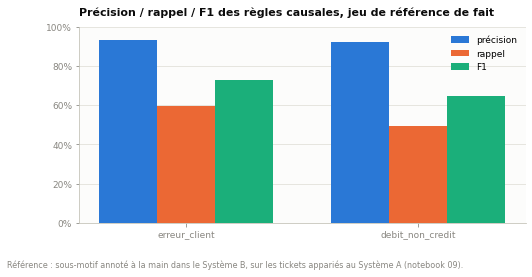

In [18]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = range(len(resultat_q8))
largeur = 0.25
ax.bar([i - largeur for i in x], resultat_q8["precision"], width=largeur, label="précision", color=viz.SERIES[0])
ax.bar(list(x), resultat_q8["rappel"], width=largeur, label="rappel", color=viz.SERIES[1])
ax.bar([i + largeur for i in x], resultat_q8["f1"], width=largeur, label="F1", color=viz.SERIES[2])
ax.set_xticks(list(x))
ax.set_xticklabels(resultat_q8["famille"])
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Précision / rappel / F1 des règles causales, jeu de référence de fait")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
viz.annoter_source(fig, "Référence : sous-motif annoté à la main dans le Système B, sur les tickets appariés au Système A (notebook 09).")
viz.sauver(fig, "13_q8_precision_rappel_f1")
plt.show()

**Lecture** — précision haute (~0,93) sur les deux familles évaluables :
quand les règles affirment `erreur_client` ou `debit_non_credit`, elles ont
raison la plupart du temps. Rappel nettement plus bas (~0,49-0,60) : les
règles manquent 4 à 5 tickets sur 10 que l'agent qualifie pourtant sans
ambiguïté dans le même domaine. **La reconstruction automatique n'est donc
pas fiable pour un comptage exhaustif** (elle sous-compte), mais elle l'est
pour hiérarchiser les familles entre elles (peu de faux positifs) — c'est
l'argument chiffré en faveur d'une classification apprise (notebook 11 § 4,
et la discussion de ce chantier sur pourquoi une méthode par règles a été
choisie en premier).

## Q9 — Reproductibilité sur un prochain export

Ce qui est déjà centralisé dans `config.py` (donc reproductible sans
modifier un notebook) : les chemins de recherche des fichiers, les seuils
(`LONGUEUR_TEXTE_MIN`, `SEUIL_COUVERTURE_JOURNALIERE`, `FENETRE_REDEPOT_JOURS`,
`FENETRE_APPARIEMENT_JOURS`), les plafonds de montant plausible, et les dates
de coupure (`DEBUT_PERIODE_OPERATIONNELLE`, `DATE_RUPTURE_COLLECTE`). La
cellule ci-dessous est un **test exécutable** : la relancer sur un nouvel
export dit immédiatement si les fichiers attendus sont trouvés, avant
d'aller plus loin.

In [19]:
print("Système A :")
print(f"  export brut trouvé          : {config.chemin_donnees()}")
print(f"  export conversations trouvé : {config.chemin_conversations()}")
print()
print("Système B -- fichiers attendus (config.FICHIERS_SYSTEME_B) :")
for nom in config.FICHIERS_SYSTEME_B:
    chemin = config.chemin_systeme_b(nom)
    statut = "OK" if chemin else "MANQUANT"
    suffixe = f" -> {chemin}" if chemin else ""
    print(f"  [{statut}] {nom}{suffixe}")

Système A :
  export brut trouvé          : /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/SRC_Intercom_Reclamation_202607201846.csv
  export conversations trouvé : /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Interc/conversations_.xlsx

Système B -- fichiers attendus (config.FICHIERS_SYSTEME_B) :
  [OK] tickets_first.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/tickets_first.xlsx
  [OK] categories.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/categories.xlsx
  [OK] groups.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/groups.xlsx
  [OK] users.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clients/dataset/Nouveau dossier 1/Nouveau dossier/users.xlsx
  [OK] ticket_assigned_users.xlsx -> /home/gauss/Bureau/Afriland/analyse des reclamation clie

**Ce qui ne se reproduit pas tout seul, et doit être revérifié à la main
sur chaque nouvel export** :

1. **`config.DATE_RUPTURE_COLLECTE` / `config.MOIS_COLLECTE_DEGRADEE`**
   décrivent un incident précis (13/03/2026). Un nouvel export peut porter
   un autre incident, à une autre date, ou aucun — le test de complétude par
   jour (`chargement.taux_completude`, notebook 02 § 3) doit être rejoué,
   pas seulement les dates recopiées.
2. **`texte.FAMILLES`** (règles causales) et **`MAPPING_TAXONOMIE`** (Q8,
   notebook 11 § 3) sont écrits à la main sur le vocabulaire observé à ce
   jour. Si le Système B ajoute ou renomme un sous-motif, le mapping doit
   être relu sur la nouvelle matrice de confusion, pas réappliqué tel quel.
3. **`config.AUDIT_MANUEL`** (notebook 04) est un décompte figé sur 20
   textes tirés avec la graine 3 -- un nouvel export change le reliquat non
   classé et rend cet audit obsolète ; il doit être refait (ou remplacé par
   la validation croisée de Q8, plus robuste, si le nouvel export permet
   encore l'appariement A↔B).
4. **Les clés d'appariement A↔B** (`consolidation.cles_a`/`cles_b`) supposent
   les mêmes noms de colonnes des deux côtés (`ticket_attributes_Numero_tel_client`,
   `contacts_contacts`, les 3 dropdowns `CHAMPS_SOUS_MOTIF`...) -- un export
   qui renomme un champ casse silencieusement l'appariement plutôt que de
   lever une erreur claire ; à vérifier explicitement, pas supposé.
5. **Le nombre de tickets et tous les pourcentages de ce notebook** doivent
   être recalculés, jamais recopiés d'un export à l'autre -- ce notebook
   entier est fait pour être rejoué intégralement (`Kernel -> Restart & Run
   All`), pas mis à jour cellule par cellule.

## Limites qui s'appliquent à l'ensemble de ce notebook

Rappel, valable pour toutes les réponses ci-dessus (détail dans les
notebooks sources cités à chaque section) :

- **Aucun journal de transactions** : le dénominateur reste absent des deux
  systèmes, le taux d'incident par transaction reste hors de portée
  (protocole § 6.1).
- **Les montants (Q4) sont des ordres de grandeur**, jamais des chiffres
  officiels — champ non validé par le métier.
- **Le dédoublonnage (Q1, Q7) sous-estime probablement les vrais doublons**
  — c'est un plancher, pas un chiffre définitif (notebook 09 § 6).
- **La correspondance de taxonomie (Q1, Q8) ne couvre que 2 des 6 familles
  causales de A** — les 4 autres n'ont pas de pont validé vers le Système B.